# TASK 1 - EDA on Retail Sales Data

## Objective

Perform Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

### Tech Stack
Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

## 1. Load Dataset

The retail sales dataset is loaded using Pandas. The dataset contains customer demographics, product information, purchase details, payment methods, and previous purchase information.

In [29]:
df = pd.read_csv('store_sales.csv')

df.head()

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10


### Initial Dataset Inspection

We will inspect the dataset shape, column data types, and missing values to understand the structure and quality of the data.

In [32]:
df.shape

(5000, 11)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   object 
 3   Category            5000 non-null   object 
 4   ItemPurchased       5000 non-null   object 
 5   Amount              5000 non-null   float64
 6   Season              5000 non-null   object 
 7   PaymentMethod       5000 non-null   object 
 8   ItemRating          5000 non-null   float64
 9   DiscountApplied(%)  5000 non-null   int64  
 10  PreviousPurchases   5000 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 429.8+ KB


In [34]:
df.isnull().sum()

CustomerID            0
Age                   0
Gender                0
Category              0
ItemPurchased         0
Amount                0
Season                0
PaymentMethod         0
ItemRating            0
DiscountApplied(%)    0
PreviousPurchases     0
dtype: int64

In [35]:
df.columns.tolist()

['CustomerID',
 'Age',
 'Gender',
 'Category',
 'ItemPurchased',
 'Amount',
 'Season',
 'PaymentMethod',
 'ItemRating',
 'DiscountApplied(%)',
 'PreviousPurchases']

## 2. Descriptive Statistics

Descriptive statistics help us understand the central tendency and variability of the numerical variables in the dataset.

In [36]:
df.mean(numeric_only=True)

CustomerID            2500.500000
Age                     45.224800
Amount                 285.090522
ItemRating               3.784160
DiscountApplied(%)      14.983600
PreviousPurchases        5.008800
dtype: float64

In [37]:
df.median(numeric_only=True)

CustomerID            2500.500
Age                     45.000
Amount                 122.485
ItemRating               3.800
DiscountApplied(%)      15.000
PreviousPurchases        5.000
dtype: float64

In [38]:
df.mode(numeric_only=True).iloc[0]

CustomerID              1.0
Age                    42.0
Amount                108.5
ItemRating              3.8
DiscountApplied(%)     16.0
PreviousPurchases       5.0
Name: 0, dtype: float64

In [39]:
df.std(numeric_only=True)

CustomerID            1443.520003
Age                     14.564995
Amount                 551.454382
ItemRating               0.681796
DiscountApplied(%)       5.988063
PreviousPurchases        2.194285
dtype: float64

In [40]:
df.describe()

,CustomerID,Age,Amount,ItemRating,DiscountApplied(%),PreviousPurchases
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,45.224800,285.090522,3.784160,14.983600,5.008800
std,1443.520003,14.564995,551.454382,0.681796,5.988063,2.194285
min,1.000000,20.000000,5.080000,1.100000,0.000000,0.000000
25%,1250.750000,33.000000,70.547500,3.300000,11.000000,3.000000
50%,2500.500000,45.000000,122.485000,3.800000,15.000000,5.000000
75%,3750.250000,58.000000,184.535000,4.300000,19.000000,6.000000
max,5000.000000,70.000000,2997.940000,5.000000,36.000000,13.000000


## 3. Time Series Analysis

The provided dataset does not contain a date or transaction-date column. Therefore, monthly and quarterly sales trends cannot be calculated reliably from the available data without introducing artificial dates.

This limitation is noted instead of creating fabricated time-series information.

In [41]:
'Date' in df.columns

False

## 4. Customer Demographics Analysis

### Age Group Distribution

Customers are grouped into age categories to understand which age groups contribute most to the retail customer base.

In [42]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]

labels = [
    'Under 18',
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56-65',
    '65+'
]

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

df['AgeGroup'].value_counts().sort_index()

AgeGroup
Under 18       0
18-25        576
26-35        928
36-45       1007
46-55       1007
56-65       1003
65+          479
Name: count, dtype: int64

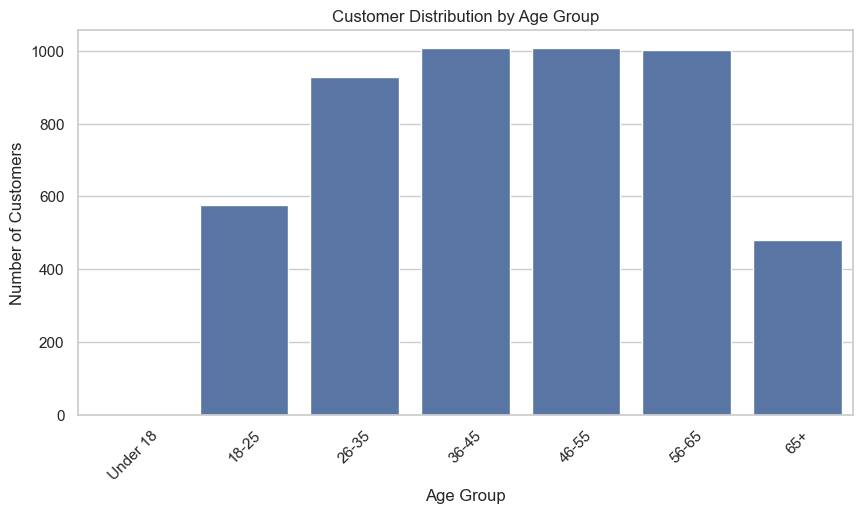

In [43]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='AgeGroup',
    order=labels
)

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

plt.show()

### Observation

The age-group distribution shows how customers are distributed across different age segments. The largest customer segment can be identified from the chart and can help the business focus its marketing campaigns on the most represented age group.

### Gender Distribution

The gender distribution is analysed to understand the composition of the customer base.

In [44]:
gender_counts = df['Gender'].value_counts()

gender_counts

Gender
Female    2504
Male      2496
Name: count, dtype: int64

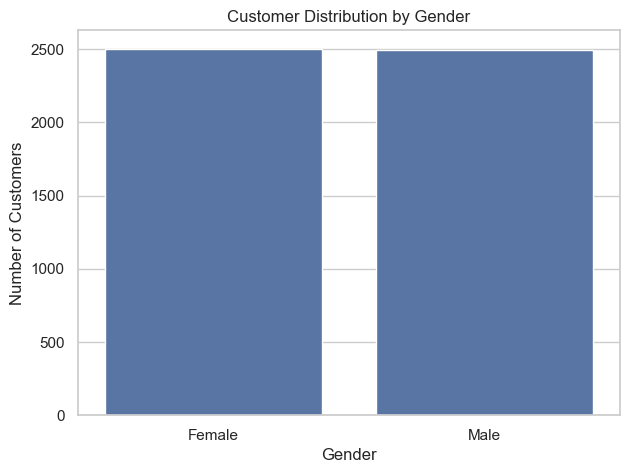

In [45]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Gender'
)

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

### Observation

The gender distribution indicates the proportion of male and female customers in the dataset. This information can help the business design more targeted marketing and product strategies.

## 5. Product Analysis

### Top 10 Best-Selling Products

The most frequently purchased products are identified to understand customer product preferences.

In [46]:
top_10_products = df['ItemPurchased'].value_counts().head(10)

top_10_products

ItemPurchased
Sandals         339
Formal Shoes    324
Sneakers        320
Yoga Mat        283
Dumbbells       277
Football        275
Jeans           238
Skincare Kit    193
Makeup Set      176
Wallet          170
Name: count, dtype: int64

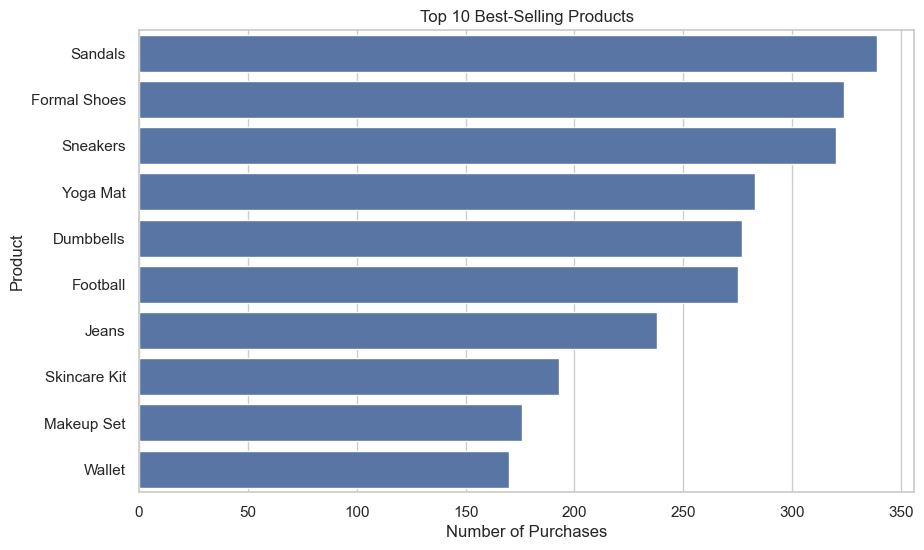

In [47]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_products.values,
    y=top_10_products.index
)

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Number of Purchases')
plt.ylabel('Product')

plt.show()

### Observation

The chart highlights the top 10 most frequently purchased products. These products represent strong customer demand and may be prioritised for inventory planning and promotional campaigns.

### Revenue by Product Category

Total revenue is calculated for each product category to identify the categories generating the highest sales value.

In [48]:
category_revenue = (
    df.groupby('Category')['Amount']
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Category
Electronics        895402.35
Footwear           141142.24
Sports             115598.11
Womens Clothing     61718.41
Mens Clothing       59680.43
Accessories         47633.83
Home                46374.22
Beauty              43887.06
Groceries           14015.96
Name: Amount, dtype: float64

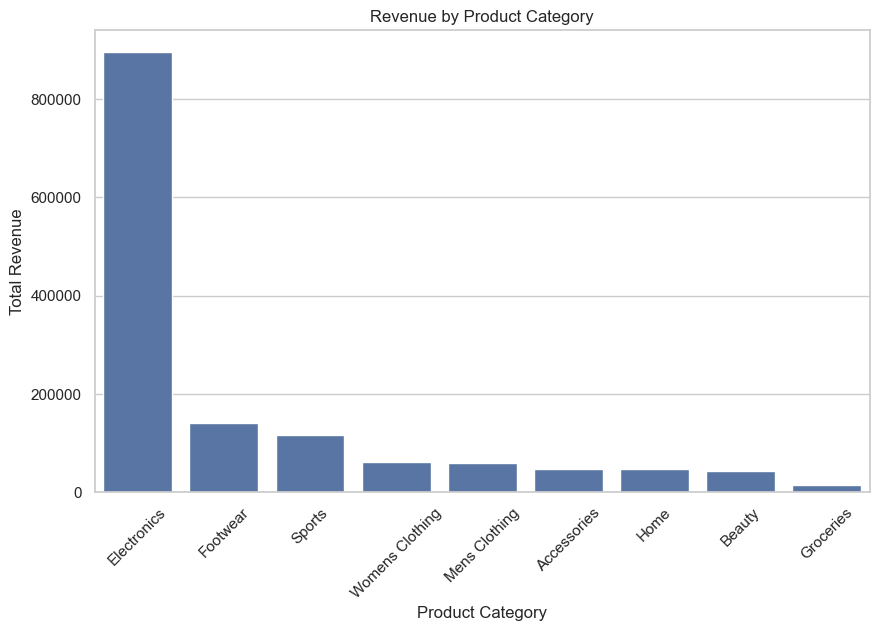

In [49]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.show()

### Observation

The revenue comparison shows which product categories contribute the most to overall sales. Higher-revenue categories can receive greater inventory availability and promotional attention.

## 6. Correlation Analysis

A correlation matrix is used to understand relationships between numerical variables in the dataset.

In [50]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

correlation_matrix

,CustomerID,Age,Amount,ItemRating,DiscountApplied(%),PreviousPurchases
CustomerID,1.000000,0.010128,0.010191,0.033162,0.012349,0.008740
Age,0.010128,1.000000,0.003056,0.003723,0.032820,0.029124
Amount,0.010191,0.003056,1.000000,0.000752,0.004291,-0.006010
ItemRating,0.033162,0.003723,0.000752,1.000000,0.158709,0.115781
DiscountApplied(%),0.012349,0.032820,0.004291,0.158709,1.000000,0.729560
PreviousPurchases,0.008740,0.029124,-0.006010,0.115781,0.729560,1.000000


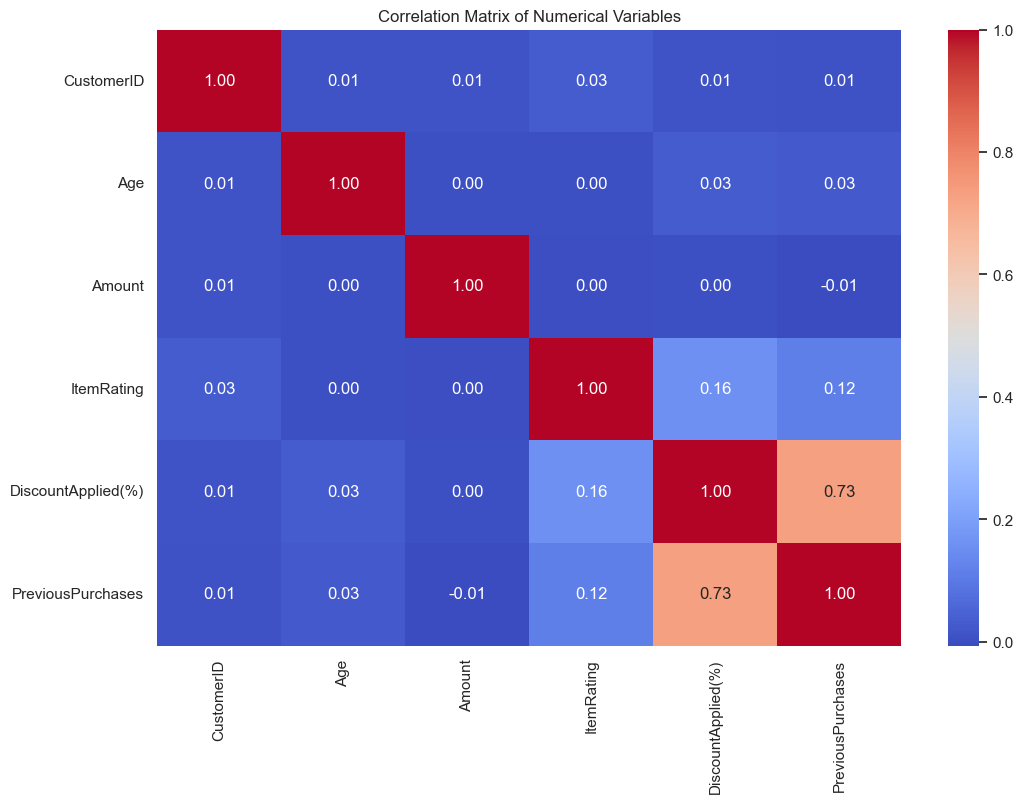

In [51]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

### Observation

The correlation heatmap shows the strength and direction of relationships between numerical variables. Strong positive or negative correlations may indicate useful relationships that can support further business analysis.

## 7. Additional Analysis

### Revenue by Season

Seasonal revenue analysis is performed to identify whether customer spending varies across different seasons.

In [52]:
season_revenue = (
    df.groupby('Season')['Amount']
    .sum()
    .sort_values(ascending=False)
)

season_revenue

Season
Spring    376029.40
Winter    354884.96
Summer    350860.36
Autumn    343677.89
Name: Amount, dtype: float64

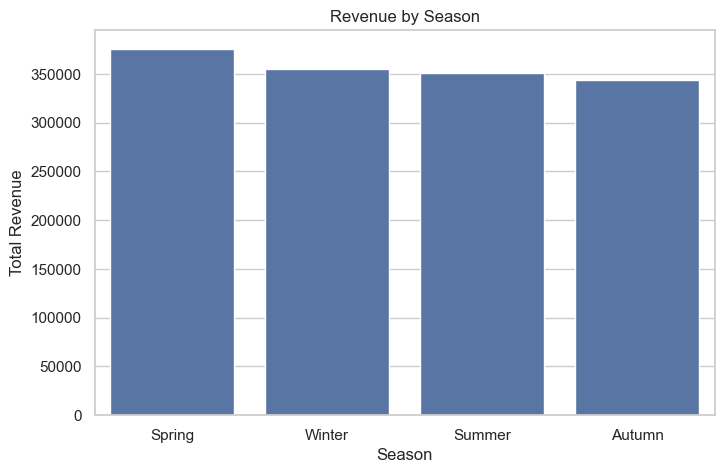

In [53]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_revenue.index,
    y=season_revenue.values
)

plt.title('Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Total Revenue')

plt.show()

### Observation

The seasonal revenue comparison helps identify periods with relatively higher or lower customer spending. The business can use this insight to plan seasonal promotions, inventory, and marketing campaigns.

### Payment Method Analysis

The distribution of payment methods is analysed to understand customer payment preferences.

In [54]:
payment_counts = df['PaymentMethod'].value_counts()

payment_counts

PaymentMethod
Card                4009
Cash on Delivery     991
Name: count, dtype: int64

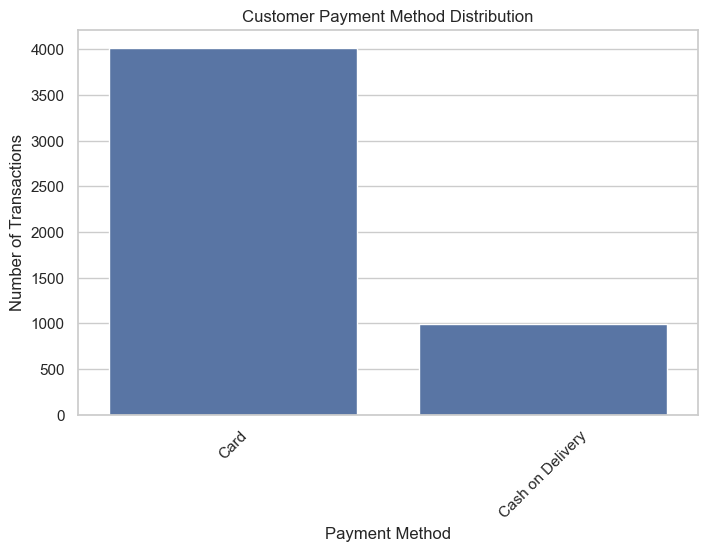

In [55]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='PaymentMethod'
)

plt.title('Customer Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)

plt.show()

### Observation

The payment-method distribution shows the preferred payment options among customers. The business can ensure that the most frequently used payment methods remain easily available during checkout.

# 8. Conclusion and Business Recommendations

Based on the exploratory data analysis, the following business recommendations can be made:

1. **Focus on high-demand products:** The top-selling products should be kept sufficiently stocked to reduce the possibility of stockouts and lost sales.

2. **Prioritise high-revenue categories:** Product categories generating the highest revenue should receive greater marketing and inventory attention.

3. **Use customer demographics for targeted marketing:** Age-group and gender analysis can be used to create more targeted promotional campaigns.

4. **Plan seasonal promotions:** Seasonal revenue patterns can be used to plan discounts, campaigns, and inventory according to customer demand.

5. **Support preferred payment methods:** The business should ensure that commonly used payment methods remain available to provide a convenient checkout experience.